# 1. Importación de librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor

In [ ]:
# lectura de los datos
proyecto_df = pd.read_excel('/content/data set Proyecto Final.xlsx')
proyecto_df.columns = proyecto_df.columns.str.strip().str.replace(',', '').str.replace(' ', '_').str.lower()
proyecto_df.head()

,desaño,desmes,h_construccion_$,h_refaccion_$,h_adquisición_nueva_$,h_adquisición_resto_$,h_otros_$,p_automotores_$,p_maquinarias_$,p-otros$,tipo_de_cambio,tasa_de_interes
0,2010.07,Jul.,4282081,152699,1544051,5660828,2220797,3837388,259273,1249680,3.934824,29.605238
1,2010.08,Ago.,4359798,153111,1550875,5703148,2259947,4014747,260441,1259990,3.937610,28.910476
2,2010.09,Set.,4005438,167185,886653,7049683,2247213,4597633,239637,1164202,3.951891,29.332273
3,2010.10,Oct.,4062383,168583,897503,7140713,2315940,4832333,250494,1193453,3.956984,29.608421
4,2010.11,Nov.,4127584,172567,906275,7226265,2411831,5125575,268533,1241870,3.967600,30.543810


In [ ]:
proyecto_df.describe()

,desaño,h_construccion_$,h_refaccion_$,h_adquisición_nueva_$,h_adquisición_resto_$,h_otros_$,p_automotores_$,p_maquinarias_$,p-otros$,tipo_de_cambio,tasa_de_interes
count,189.000000,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,189.000000,189.000000
mean,2017.938254,2.621550e+07,3.771733e+06,2.095437e+08,1.195724e+08,8.430568e+07,2.695213e+08,3.864622e+07,1.174013e+08,206.279592,53.790515
std,4.571042,5.475953e+07,7.470863e+06,5.686017e+08,3.243851e+08,2.378353e+08,6.325560e+08,8.426171e+07,2.790139e+08,390.162329,22.553534
min,2010.070000,2.207474e+06,1.526990e+05,8.866530e+05,5.660828e+06,2.220797e+06,3.837388e+06,2.396370e+05,1.164202e+06,3.934824,28.910476
25%,2014.060000,3.412578e+06,1.044559e+06,9.047150e+06,9.373211e+06,5.202887e+06,1.706154e+07,1.137943e+06,4.165550e+06,8.125515,37.498182
50%,2018.050000,9.000642e+06,2.045756e+06,9.263400e+07,2.957281e+07,1.550378e+07,4.445133e+07,6.112407e+06,8.479135e+06,23.668748,46.034737
75%,2022.040000,2.753194e+07,2.787504e+06,1.178265e+08,3.889502e+07,2.740872e+07,9.191814e+07,2.277430e+07,5.562232e+07,113.334474,67.652273
max,2026.030000,3.258690e+08,4.039955e+07,3.461931e+09,1.465120e+09,1.232587e+09,2.791996e+09,3.859431e+08,1.168717e+09,1449.334662,138.748947


In [ ]:
proyecto_tc = [col for col in proyecto_df.columns if col not in ["desaño", 'desmes',	"tipo_de_cambio",	"tasa_de_interes"]]
X = proyecto_df[['tipo_de_cambio','tasa_de_interes']]
# Definimos nuestra Variables objetivos en este caso dos
y = proyecto_df[proyecto_tc]


In [ ]:
# Dividimos los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Saclamos los datos
scaler_2 = StandardScaler()
X_train_scaled = scaler_2.fit_transform(X_train)
X_test_scaled = scaler_2.transform(X_test)

In [ ]:
model_tree = DecisionTreeRegressor(random_state=42)
multi_tree = MultiOutputRegressor(model_tree)


In [ ]:
param_grid2 = {
    'estimator__max_depth': [3,5,10,None],
    'estimator__min_samples_split': [2, 5, 10],
}

#'estimator__max_depth': [None, 10, 20, 30],
 #   'estimator__min_samples_split': [2, 5, 10],

In [ ]:
grid_search2 = GridSearchCV(multi_tree, param_grid2, cv=5, scoring='neg_mean_squared_error')
grid_search2.fit(X_train_scaled, y_train)

GridSearchCV(cv=5,
             estimator=MultiOutputRegressor(estimator=DecisionTreeRegressor(random_state=42)),
             param_grid={'estimator__max_depth': [3, 5, 10, None],
                         'estimator__min_samples_split': [2, 5, 10]},
             scoring='neg_mean_squared_error')

In [ ]:
mejor_modelo_tree = grid_search2.best_estimator_
y_pred = mejor_modelo_tree.predict(X_test_scaled)

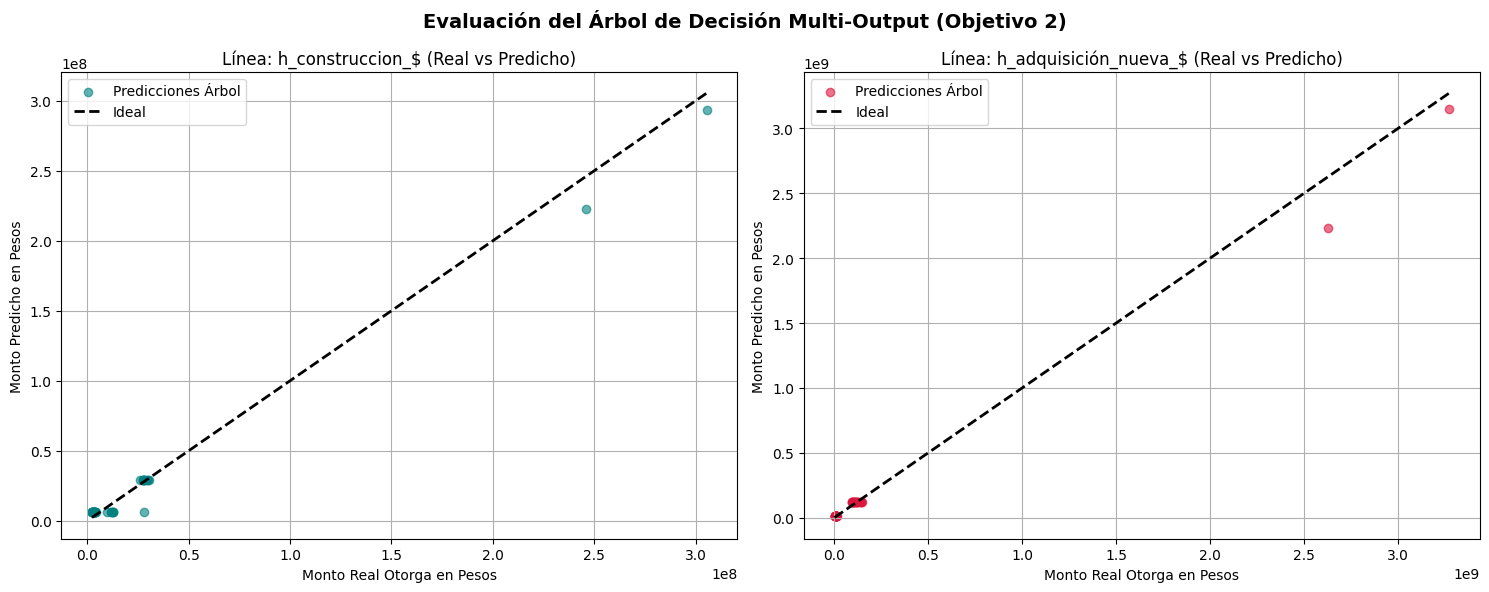

=== DESEMPEÑO DEL MODELO ===
R² Score para [h_construccion_$]: 0.9887
R² Score para [h_refaccion_$]: 0.9952
R² Score para [h_adquisición_nueva_$]: 0.9891
R² Score para [h_adquisición_resto_$]: 0.9997
R² Score para [h_otros_$]: 0.9935
R² Score para [p_automotores_$]: 0.9953
R² Score para [p_maquinarias_$]: 0.9959
R² Score para [p-otros$]: 0.9981


In [ ]:
# Graficamos 2 de las líneas más importantes para no saturar la pantalla: Construcción e Hipotecarios Nuevos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Créditos para Construcción (Columna 0 de las líneas de crédito)
ax1.scatter(y_test.iloc[:, 0], y_pred[:, 0], color='teal', alpha=0.6, label='Predicciones Árbol')
ax1.plot([y_test.iloc[:, 0].min(), y_test.iloc[:, 0].max()],
         [y_test.iloc[:, 0].min(), y_test.iloc[:, 0].max()], 'k--', lw=2, label='Ideal')
ax1.set_title(f'Línea: {proyecto_tc[0]} (Real vs Predicho)')
ax1.set_xlabel('Monto Real Otorga en Pesos')
ax1.set_ylabel('Monto Predicho en Pesos')
ax1.grid(True)
ax1.legend()

# Subplot 2: Créditos Adquisición Nueva (Columna 2 de las líneas de crédito)
ax2.scatter(y_test.iloc[:, 2], y_pred[:, 2], color='crimson', alpha=0.6, label='Predicciones Árbol')
ax2.plot([y_test.iloc[:, 2].min(), y_test.iloc[:, 2].max()],
         [y_test.iloc[:, 2].min(), y_test.iloc[:, 2].max()], 'k--', lw=2, label='Ideal')
ax2.set_title(f'Línea: {proyecto_tc[2]} (Real vs Predicho)')
ax2.set_xlabel('Monto Real Otorga en Pesos')
ax2.set_ylabel('Monto Predicho en Pesos')
ax2.grid(True)
ax2.legend()

plt.suptitle('Evaluación del Árbol de Decisión Multi-Output (Objetivo 2)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Imprimir métrica global de control
print("=== DESEMPEÑO DEL MODELO ===")
for i, col_name in enumerate(proyecto_tc):
    r2_col = r2_score(y_test.iloc[:, i], y_pred[:, i])
    print(f"R² Score para [{col_name}]: {r2_col:.4f}")

In [ ]:
# PASO 5: Simulación con Nuevos Datos Macroeconómicos
# ==========================================
print("\n" + "="*60)
print("  NUEVA ENTRADA DE DATOS: PRUEBA DE ESTRÉ")
print("="*60)

# El comité del banco define un nuevo escenario: Dólar a $1.300 y Tasa de Interés al 75%
nuevo_escenario_macro = {
    'tipo_de_cambio': 950.73,
    'tasa_de_interes':115.60
}

# Convertimos a DataFrame respetando las columnas
X_nueva_macro = pd.DataFrame([nuevo_escenario_macro])

# Escalamos la entrada con los parámetros estadísticos del entrenamiento
X_nueva_macro_scaled = scaler_2.transform(X_nueva_macro)

# Predecimos el comportamiento de las 8 líneas en simultáneo
prediccion_creditos = mejor_modelo_tree.predict(X_nueva_macro_scaled)

print(f" Evaluado -> Dólar: ${nuevo_escenario_macro['tipo_de_cambio']} | Tasa: {nuevo_escenario_macro['tasa_de_interes']}%")
print(f" Proyectada de Créditos por Línea:")


# Recorremos y mostramos la predicción para cada una de las 8 líneas de crédito
for i, col_name in enumerate(proyecto_tc):
    monto_estimado = prediccion_creditos[0][i]
    print(f" -> {col_name:25}: ${monto_estimado:,.2f} ARS")
print("="*60)


  NUEVA ENTRADA DE DATOS: PRUEBA DE ESTRÉS MACRO
[IN] Escenario Evaluado -> Dólar: $950.73 | Tasa: 115.6%
[OUT] Demanda Proyectada de Créditos por Línea:
------------------------------------------------------------
 -> h_construccion_$         : $28,887,521.39 ARS
 -> h_refaccion_$            : $2,762,375.03 ARS
 -> h_adquisición_nueva_$    : $122,485,982.23 ARS
 -> h_adquisición_resto_$    : $39,867,055.00 ARS
 -> h_otros_$                : $105,332,736.50 ARS
 -> p_automotores_$          : $830,653,422.00 ARS
 -> p_maquinarias_$          : $121,932,699.67 ARS
 -> p-otros$                 : $465,680,304.00 ARS


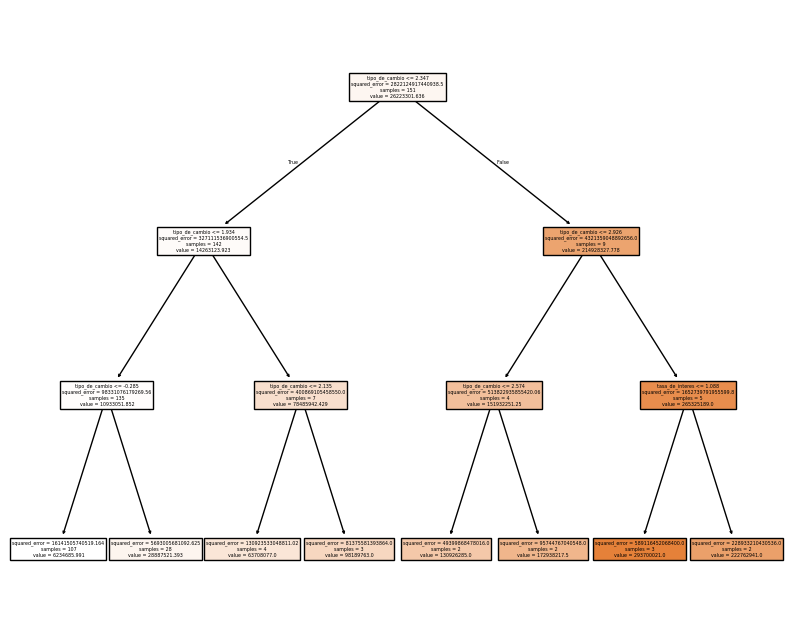

In [ ]:
plt.figure(figsize=(10, 8))
plot_tree(mejor_modelo_tree.estimators_[0], filled=True, feature_names=X.columns, class_names=y.columns)
plt.show()

# Etapa Final usando K_Means


In [ ]:
proyecto_tc = [col for col in proyecto_df.columns if col not in ["desaño", 'desmes',	"tipo_de_cambio",	"tasa_de_interes"]]
X = proyecto_df[['tipo_de_cambio','tasa_de_interes']]
# Definimos nuestra Variables objetivos en este caso dos
y = proyecto_df[proyecto_tc]

In [ ]:
#proyecto = ["tipo_de_cambio","tasa_de_interes"]
pro_kmean = proyecto_df[["tipo_de_cambio","tasa_de_interes"]]

In [ ]:
# Escalado
scaler_kmean = StandardScaler()
pro_kmean_scaled = scaler_kmean.fit_transform(pro_kmean)

In [ ]:
# Entrenamiento de K-Means
kmean = KMeans(n_clusters=3, random_state=42, n_init=10)
proyecto_df['cluster'] = kmean.fit_predict(pro_kmean_scaled)
proyecto_df.head()

,desaño,desmes,h_construccion_$,h_refaccion_$,h_adquisición_nueva_$,h_adquisición_resto_$,h_otros_$,p_automotores_$,p_maquinarias_$,p-otros$,tipo_de_cambio,tasa_de_interes,cluster
0,2010.07,Jul.,4282081,152699,1544051,5660828,2220797,3837388,259273,1249680,3.934824,29.605238,0
1,2010.08,Ago.,4359798,153111,1550875,5703148,2259947,4014747,260441,1259990,3.937610,28.910476,0
2,2010.09,Set.,4005438,167185,886653,7049683,2247213,4597633,239637,1164202,3.951891,29.332273,0
3,2010.10,Oct.,4062383,168583,897503,7140713,2315940,4832333,250494,1193453,3.956984,29.608421,0
4,2010.11,Nov.,4127584,172567,906275,7226265,2411831,5125575,268533,1241870,3.967600,30.543810,0


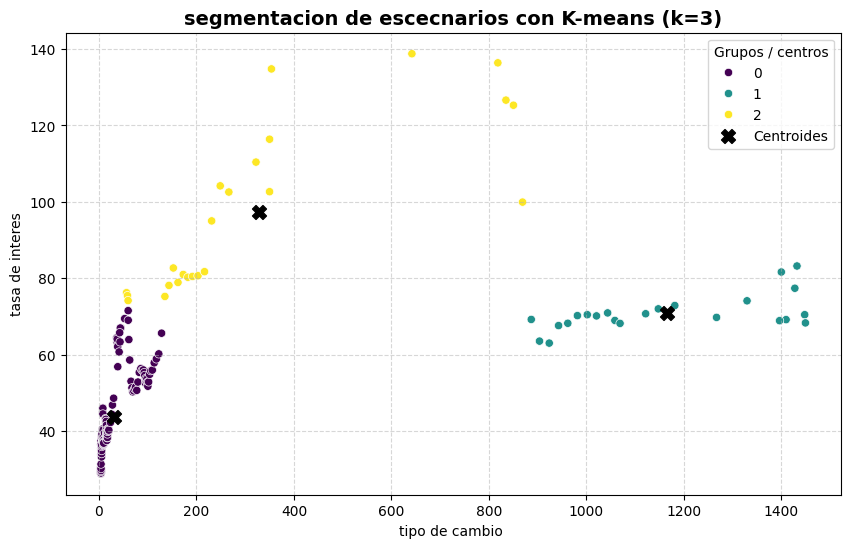

In [ ]:
# graficos
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='tipo_de_cambio',
    y='tasa_de_interes',
    hue='cluster',
    data=proyecto_df,
    palette='viridis'
    )
#escalomos los centroides
centroides_escalados = kmean.cluster_centers_
centroides_reales= scaler_kmean.inverse_transform(kmean.cluster_centers_)
# Dibukamos los Centorides en cada escenario
plt.scatter(
    centroides_reales[:, 0],
    centroides_reales[:, 1],
    marker='X',
    c='black',
    s=100,
    label='Centroides'
)
plt.title("segmentacion de escecnarios con K-means (k=3)", fontsize=14, fontweight='bold')
plt.xlabel("tipo de cambio ")
plt.ylabel("tasa de interes")
plt.legend(title="Grupos / centros")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [ ]:
# Simulamos datos riesgo con nuevos datos
nuevo_datos_escenario = {
    'tipo_de_cambio': 800.0,
    'tasa_de_interes':130.0
}
nuevo_escenario = pd.DataFrame([nuevo_datos_escenario])
#Escalamos
nuevo_escenario_scaled = scaler_kmean.transform(nuevo_escenario)
# El modelo clacula a que cluster pertenece el nuevo dato
cluster_asignado = kmean.predict(nuevo_escenario_scaled)[0]

print(f"Escenario Evaluado -> Dólar: ${nuevo_datos_escenario['tipo_de_cambio']} | Tasa: {nuevo_datos_escenario['tasa_de_interes']}%")
print(f"Demanda Proyectada de Créditos por Línea:")

if cluster_asignado == 0:
    print(" ESCENARIO ESTABLE: Tasas bajas, tipo de cambio controlado")
    print("ACCION: Luz verde para colocar prestamos")
elif cluster_asignado == 1:
    print("ESCENARIO VOLATIL: Tasas medias, dolar subiendo")
    print("ACCION: Luiz amarilla, ajustar plazos")
else:
    print("ESCENARIO DE RIESGO: Tasas altas, devaluacion acelerada. ")
    print("ACCION: Luz roja, restringir prestamos por riesgo de pago")


[IN] Escenario Evaluado -> Dólar: $800.0 | Tasa: 130.0%
[OUT] Demanda Proyectada de Créditos por Línea:
------------------------------------------------------------
ESCENARIO DE RIESGO: Tasas altas, devaluacion acelerada. 
ACCION: Luz roja, restringir prestamos por riesgo de pago
